In [1]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
before_logits = np.load("before_wrapper_logits.npy")
after_logits = np.load("wrapper_logits.npy")

In [7]:
# replace inf with 0
after_logits[np.isinf(after_logits)] = 0

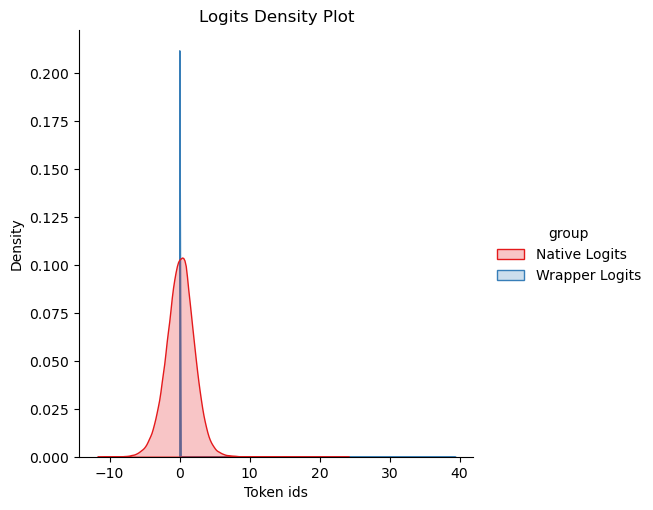

In [13]:
# 假设输入的两个向量
L = before_logits.shape[0]

# 创建数据集并添加标识
import pandas as pd
df = pd.DataFrame({
    'value': np.concatenate([before_logits, after_logits]),
    'group': ['Native Logits'] * L + ['Wrapper Logits'] * L
})

# 使用 seaborn 的 displot 绘制概率密度图
sns.displot(df, x='value', hue='group', kind='kde', fill=True, palette='Set1')

# 设置标题和标签
plt.title('Logits Density Plot')
plt.xlabel('Token ids')
plt.ylabel('Density')

# 显示图像
plt.savefig("logits_density_plot.svg")